170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 100s 1us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 - 183s - 293ms/step - accuracy: 0.1942 - loss: 2.9665 - val_accuracy: 0.3141 - val_loss: 1.9115
Epoch 2/20
625/625 - 173s - 278ms/step - accuracy: 0.2639 - loss: 2.4903 - val_accuracy: 0.3882 - val_loss: 1.6927
Epoch 3/20
625/625 - 205s - 328ms/step - accuracy: 0.2917 - loss: 2.3045 - val_accuracy: 0.4008 - val_loss: 1.6829
Epoch 4/20
625/625 - 176s - 282ms/step - accuracy: 0.3131 - loss: 2.1669 - val_accuracy: 0.4322 - val_loss: 1.5886
Epoch 5/20
625/625 - 177s - 284ms/step - accuracy: 0.3307 - loss: 2.0705 - val_accuracy: 0.4498 - val_loss: 1.5179
Epoch 6/20
625/625 - 181s - 290ms/step - accuracy: 0.3468 - loss: 1.9627 - val_accuracy: 0.4593 - val_loss: 1.5170
Epoch 7/20
625/625 - 185s - 296ms/step - accuracy: 0.3609 - loss: 1.9026 - val_accuracy: 0.4767 - val_loss: 1.4603
Epoch 8/20
625/625 - 182s - 292ms/step - accuracy: 0.3691 - loss: 1.8424 - val_accuracy: 0.4820 - val_loss: 1.4363
Epoch 9/20
625/625 - 181s - 289ms/step - accuracy: 0.3792 - loss: 1.7981 - val_accuracy: 0.

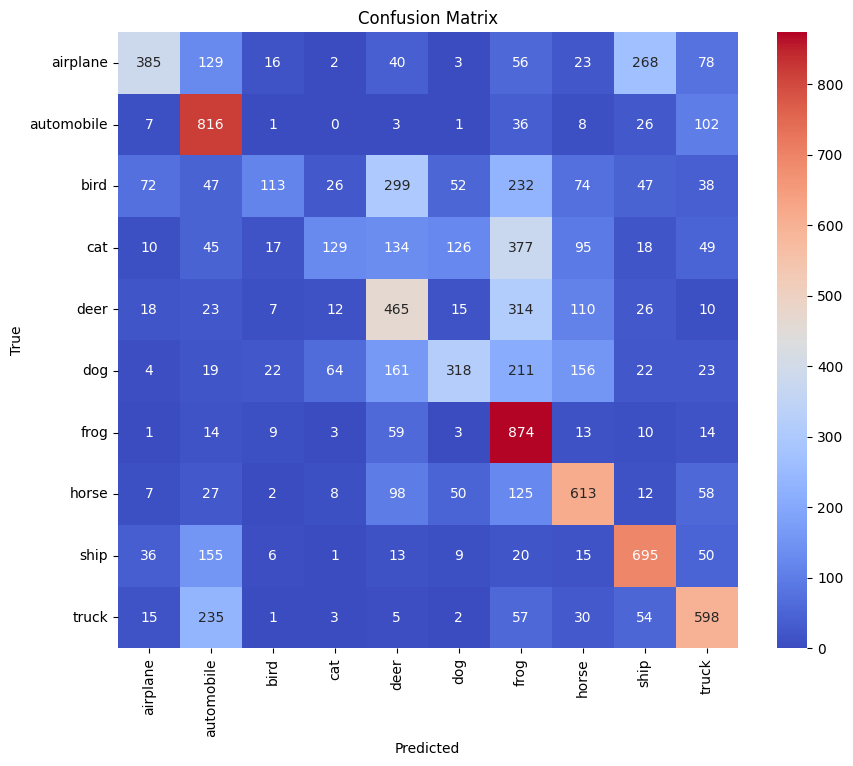

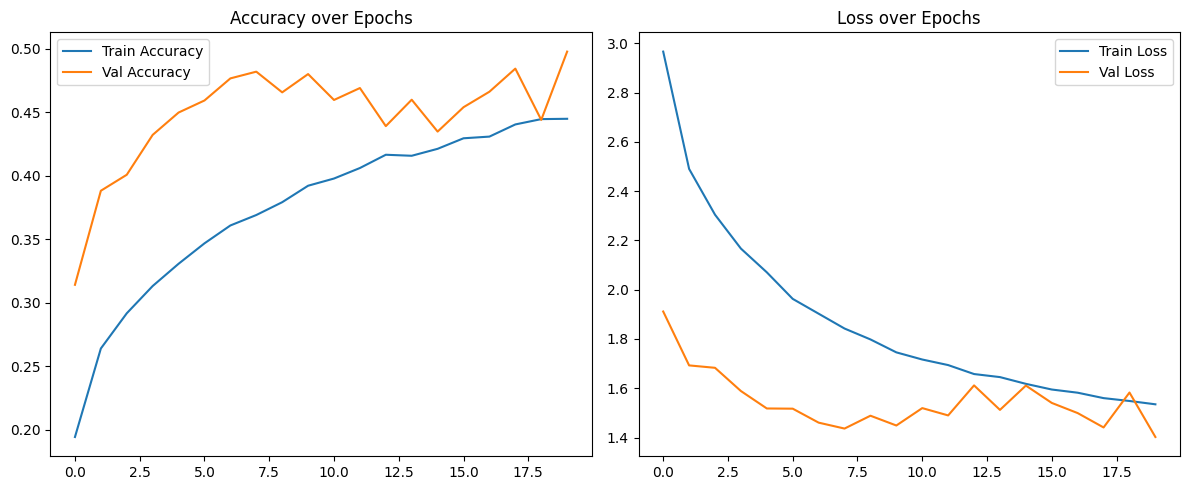

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load and normalize CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Manual train/validation split (80/20)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.2, stratify=y_train_full, random_state=42)

# ImageDataGenerators
train_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)
val_gen = ImageDataGenerator()

train_flow = train_gen.flow(x_train, y_train, batch_size=64)
val_flow = val_gen.flow(x_val, y_val, batch_size=64)

# Model architecture
def build_model():
    model = Sequential()
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2,2)))
    model.add(Dropout(0.35))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(10, activation='softmax'))
    return model

model = build_model()
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Training loop
history = model.fit(
    train_flow,
    epochs=20,
    validation_data=val_flow,
    verbose=2
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

# Metrics and plots
y_pred = np.argmax(model.predict(x_test), axis=1)
y_true = y_test.flatten()

print(classification_report(y_true, y_pred, target_names=[
    "airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"
]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=[
    "airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"
], yticklabels=[
    "airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"
], cmap="coolwarm")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Loss over Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# HyperParameter Tuning: I replaced optimizer from Adam to SGD with learning rate of 0.001
# Results :
# - Test accuracy decreased from ~73% (Adam) to ~50% (SGD)
# - SGD showed slower convergence and more unstable validation metrics
# - Training curves indicate SGD requires more tuning (higher learning rate or momentum)
